In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [5]:
training_df = pd.read_csv("../datasets/training.csv")
training_df.set_index("date", inplace=True)

X_train = training_df.iloc[:,1:]
y_train = training_df.Appliances
training_df

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.00,45.566667,...,18.2000,48.900000,17.033333,45.530000,6.600000,733.5,92.000000,7.000000,63.000000,5.300000
2016-01-11 17:10:00,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.00,45.992500,...,18.2000,48.863333,17.066667,45.560000,6.483333,733.6,92.000000,6.666667,59.166667,5.200000
2016-01-11 17:30:00,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.89,45.723333,...,18.1000,48.590000,17.000000,45.400000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000
2016-01-11 17:40:00,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.89,45.530000,...,18.1000,48.590000,17.000000,45.400000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000
2016-01-11 17:50:00,50,40,19.890000,46.026667,19.200000,44.500000,19.790000,44.933333,18.89,45.730000,...,18.1000,48.590000,17.000000,45.290000,6.016667,734.0,92.000000,5.333333,43.833333,4.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-27 17:00:00,110,0,25.600000,47.193333,25.968571,42.528571,27.390000,41.030000,24.70,45.626667,...,24.6000,50.863333,23.200000,46.751429,23.000000,755.2,55.000000,3.000000,22.000000,13.400000
2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.70,45.590000,...,24.7000,50.074000,23.200000,46.790000,22.733333,755.2,55.666667,3.333333,23.666667,13.333333
2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.70,45.590000,...,24.7000,49.790000,23.200000,46.790000,22.600000,755.2,56.000000,3.500000,24.500000,13.300000


In [6]:
testing_df = pd.read_csv("../datasets/testing.csv")
testing_df.set_index("date", inplace=True)
X_test = testing_df.iloc[:, 1:]
y_test = testing_df.Appliances
testing_df

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:20:00,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,45.890000,...,18.200000,48.730000,17.000000,45.500000,6.366667,733.700000,92.000000,6.333333,55.333333,5.100000
2016-01-11 18:50:00,580,60,20.066667,46.396667,19.426667,44.400000,19.790000,44.826667,19.000000,46.430000,...,18.066667,48.633333,16.890000,45.290000,5.983333,734.433333,91.166667,5.833333,40.000000,4.616667
2016-01-11 19:00:00,430,50,20.133333,48.000000,19.566667,44.400000,19.890000,44.900000,19.000000,46.363333,...,18.066667,48.560000,16.963333,45.290000,6.000000,734.500000,91.000000,6.000000,40.000000,4.600000
2016-01-11 19:10:00,250,40,20.260000,52.726667,19.730000,45.100000,19.890000,45.493333,19.000000,47.223333,...,18.033333,48.666667,16.890000,45.326667,6.000000,734.616667,90.500000,6.000000,40.000000,4.516667
2016-01-11 19:30:00,100,10,20.566667,53.893333,20.033333,46.756667,20.100000,48.466667,19.000000,48.490000,...,18.150000,49.200000,16.890000,45.326667,6.000000,734.850000,89.500000,6.000000,40.000000,4.350000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-27 15:00:00,60,0,25.500000,45.933333,26.277143,41.000000,28.356667,40.560000,24.666667,45.400000,...,23.963333,49.000000,23.100000,46.590000,21.800000,755.800000,59.000000,2.000000,21.000000,13.300000
2016-05-27 15:30:00,80,0,25.500000,45.590000,26.100000,41.000000,28.200000,40.126667,24.700000,45.163333,...,24.000000,48.790000,23.166667,46.590000,22.300000,755.650000,57.000000,2.000000,22.000000,13.250000
2016-05-27 16:30:00,220,0,25.426667,46.060000,26.000000,41.700000,28.000000,40.760000,24.700000,45.400000,...,24.356667,51.333333,23.200000,46.700000,22.900000,755.350000,55.000000,2.500000,22.500000,13.300000


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred

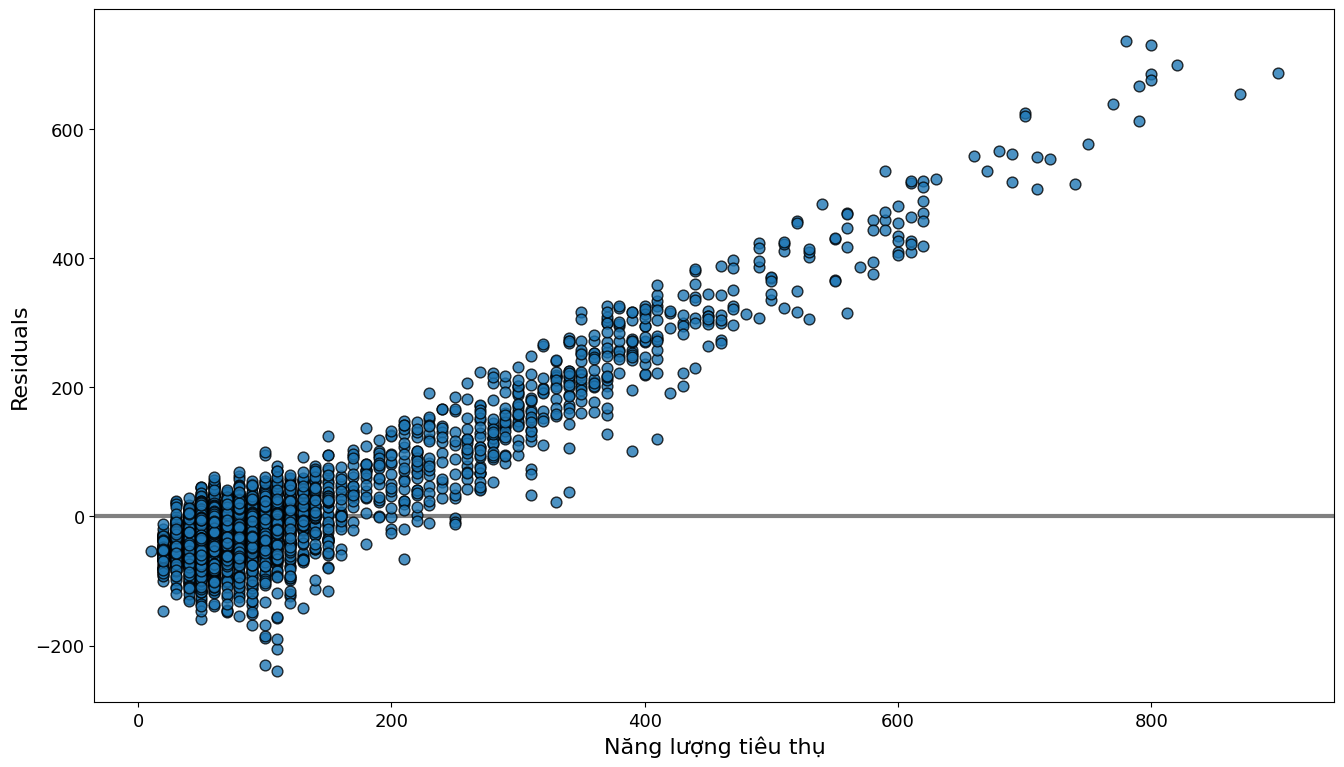

In [26]:
plt.figure(figsize=(16, 9))
plt.xlabel("Năng lượng tiêu thụ", fontsize=16)
plt.xticks(fontsize=13)
plt.ylabel("Residuals", fontsize=16)
plt.yticks(fontsize=13)
plt.axhline(y=0, color='gray', linewidth=3, zorder=1)

plt.scatter(y_test, residuals, edgecolor='k', s=60, alpha=0.8)
plt.savefig("../fig/LR_fig8.png", dpi=300, bbox_inches="tight")
plt.show()